In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
# ── 1. LOAD DATA
df = pd.read_csv('Telco-Customer-Churn.csv')
print(df.shape)       # (7043, 21), original dataset.
print(df.head())
print(df.info())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [3]:
# ── 2. FIX MISSING VALUES 
# TotalCharges has blank strings — convert to numeric first
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [4]:
# Fill missing TotalCharges with the column mean
avg_total = df['TotalCharges'].mean()
df['TotalCharges'].fillna(avg_total, inplace=True)

print(df.isnull().sum())  # confirm no more nulls

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


C:\Users\Arij\AppData\Local\Temp\ipykernel_16392\1961870752.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(avg_total, inplace=True)


In [5]:
# ── 3. ENCODE CATEGORICAL → NUMERIC 
# Convert Churn to binary: Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [6]:
# Drop CustomerID (not useful for ML)
df.drop('customerID', axis=1, inplace=True)

In [7]:
# One-hot encode all remaining categorical columns
df_encoded = pd.get_dummies(df)
print(df_encoded.shape)

# final dataset ready for modelling contains 46 features (after encoding)
print(df_encoded.head())

(7043, 46)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Female  \
0              0       1           29.85         29.85      0           True   
1              0      34           56.95       1889.50      0          False   
2              0       2           53.85        108.15      1          False   
3              0      45           42.30       1840.75      0          False   
4              0       2           70.70        151.65      1           True   

   gender_Male  Partner_No  Partner_Yes  Dependents_No  ...  \
0        False       False         True           True  ...   
1         True        True        False           True  ...   
2         True        True        False           True  ...   
3         True        True        False           True  ...   
4        False        True        False           True  ...   

   StreamingMovies_Yes  Contract_Month-to-month  Contract_One year  \
0                False                     True            

#### Data Split

In [8]:
# ── 4. TRAIN / VALIDATION / TEST SPLIT
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [10]:
# Step 1: split off 10% test set
X_remaining, X_test, y_remaining, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42
)

In [11]:
# Step 2: split remaining into 80% train, 10% val
X_train, X_val, y_train, y_val = train_test_split(
    X_remaining, y_remaining, test_size=0.111, random_state=42  # 0.111 ≈ 10/90
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 5634, Val: 704, Test: 705


#### Checking y value

In [12]:
# Check and fix NaN in y
print("NaN in y_train:", y_train.isna().sum())
print("NaN in y_val:", y_val.isna().sum())

# Fix: drop NaN rows
y_train = y_train.dropna()
X_train = X_train.loc[y_train.index]

y_val = y_val.dropna()
X_val = X_val.loc[y_val.index]

print("Fixed! y_train values:", y_train.unique())

NaN in y_train: 0
NaN in y_val: 0
Fixed! y_train values: [1 0]


### ML Starts here
#### Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report


# X_train, X_val, X_test, y_train, y_val, y_test already defined above

# --- Define 3 pipelines
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(
            n_estimators=200, max_depth=10,
            min_samples_split=5, class_weight='balanced', random_state=42
        ))  # ← your GridSearch best params!
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('model', DecisionTreeClassifier(class_weight='balanced', random_state=42))
    ])
}

# --- Train on X_train, evaluate on X_val ---
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    print(f"\n--- {name} ---")
    print(classification_report(y_val, pipe.predict(X_val)))


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.92      0.73      0.81       526
           1       0.51      0.82      0.63       178

    accuracy                           0.75       704
   macro avg       0.71      0.77      0.72       704
weighted avg       0.82      0.75      0.77       704


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.89      0.79      0.84       526
           1       0.53      0.71      0.61       178

    accuracy                           0.77       704
   macro avg       0.71      0.75      0.72       704
weighted avg       0.80      0.77      0.78       704


--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       526
           1       0.52      0.52      0.52       178

    accuracy                           0.76       704
   macro avg       0.68      0.68      0.68       704

In [14]:
#  SEARCHING for the best value
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 15, None],
    'n_estimators': [50, 100, 200],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [15]:
# Use the best parameters found by GridSearchCV
rf_best = RandomForestClassifier(
    max_depth=10,
    min_samples_split=5,
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_best.fit(X_train, y_train)

# Evaluate on validation set
from sklearn.metrics import classification_report
print(classification_report(y_val, rf_best.predict(X_val)))

              precision    recall  f1-score   support

           0       0.88      0.79      0.83       526
           1       0.53      0.70      0.60       178

    accuracy                           0.77       704
   macro avg       0.71      0.74      0.72       704
weighted avg       0.79      0.77      0.78       704



In [16]:
# Collect all models
models = {
    'Logistic Regression': pipelines['Logistic Regression'],
    'Random Forest (default)': pipelines['Random Forest'],
    'Decision Tree': pipelines['Decision Tree'],
    'Random Forest (best params)': rf_best  # ← your GridSearch tuned model
}

# Compare on validation set
for name, model in models.items():
    print(f"\n--- {name} ---")
    print(classification_report(y_val, model.predict(X_val)))


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.92      0.73      0.81       526
           1       0.51      0.82      0.63       178

    accuracy                           0.75       704
   macro avg       0.71      0.77      0.72       704
weighted avg       0.82      0.75      0.77       704


--- Random Forest (default) ---
              precision    recall  f1-score   support

           0       0.89      0.79      0.84       526
           1       0.53      0.71      0.61       178

    accuracy                           0.77       704
   macro avg       0.71      0.75      0.72       704
weighted avg       0.80      0.77      0.78       704


--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       526
           1       0.52      0.52      0.52       178

    accuracy                           0.76       704
   macro avg       0.68      0.68      0.68

In [17]:
print("--- FINAL TEST: Logistic Regression ---")
print(classification_report(y_test, pipelines['Logistic Regression'].predict(X_test)))

--- FINAL TEST: Logistic Regression ---
              precision    recall  f1-score   support

           0       0.92      0.74      0.82       511
           1       0.55      0.84      0.66       194

    accuracy                           0.77       705
   macro avg       0.74      0.79      0.74       705
weighted avg       0.82      0.77      0.78       705



LR  AUC: 0.856
RF  AUC: 0.848
DT  AUC: 0.676


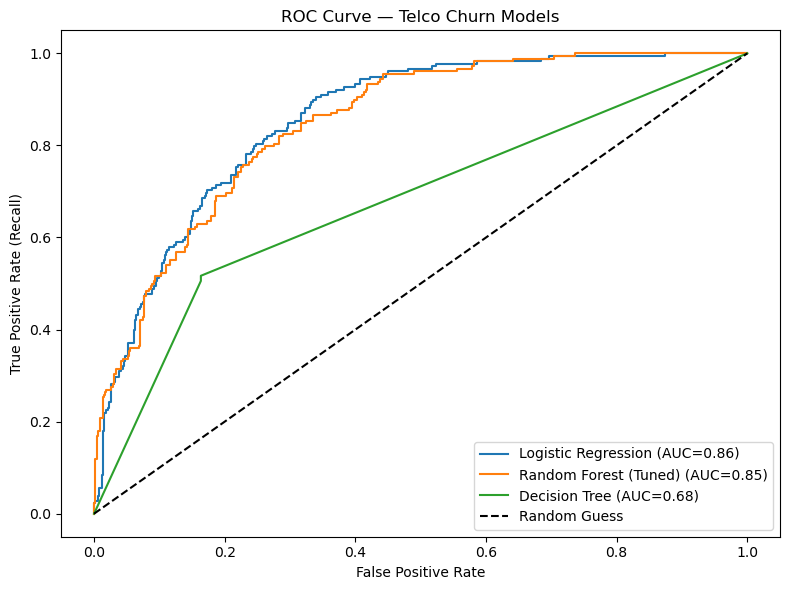

In [18]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# ✅ Use pipelines + rf_best
lr_probs = pipelines['Logistic Regression'].predict_proba(X_val)[:, 1]
rf_probs = rf_best.predict_proba(X_val)[:, 1]
dt_probs = pipelines['Decision Tree'].predict_proba(X_val)[:, 1]

# AUC scores
print("LR  AUC:", round(roc_auc_score(y_val, lr_probs), 3))
print("RF  AUC:", round(roc_auc_score(y_val, rf_probs), 3))
print("DT  AUC:", round(roc_auc_score(y_val, dt_probs), 3))

# Plot all 3 curves
plt.figure(figsize=(8, 6))
for name, probs in [("Logistic Regression", lr_probs),
                    ("Random Forest (Tuned)", rf_probs),
                    ("Decision Tree", dt_probs)]:
    fpr, tpr, _ = roc_curve(y_val, probs)
    auc = roc_auc_score(y_val, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Telco Churn Models")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png")
plt.show()

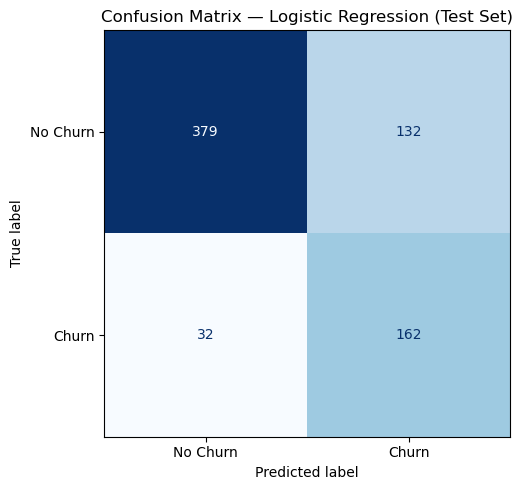

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Get predictions from best model (Logistic Regression) on test set
y_pred = pipelines['Logistic Regression'].predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues", ax=ax, colorbar=False)

ax.set_title("Confusion Matrix — Logistic Regression (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Feature Importances (Logistic Regression):


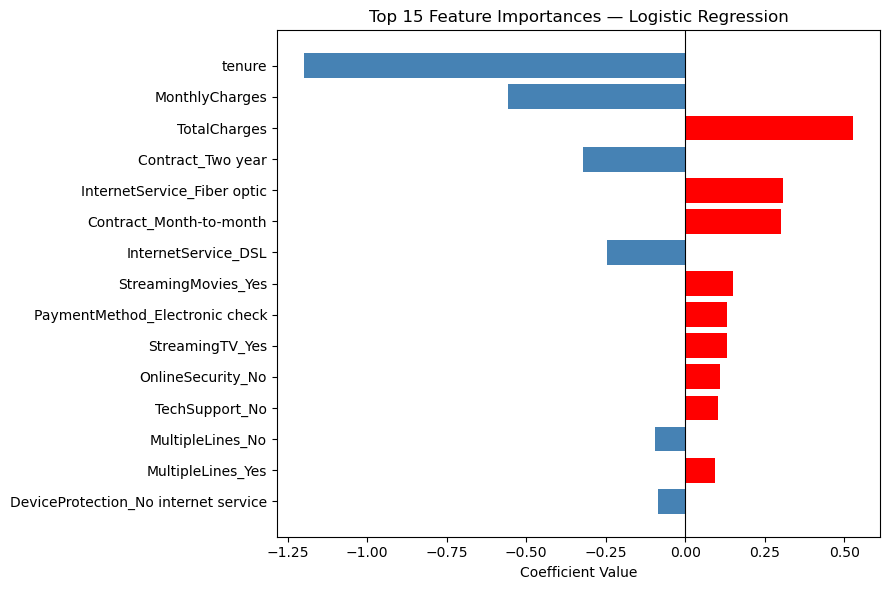

In [26]:
model = pipelines['Logistic Regression'].named_steps['model']

all_features = X_train.columns.tolist()

# Build DataFrame of coefficients
feat_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': model.coef_[0]
})

# Sort by absolute value, take top 15
feat_df['abs_coef'] = feat_df['Coefficient'].abs()
feat_df = feat_df.sort_values('abs_coef', ascending=False).head(15)

print('Feature Importances (Logistic Regression):')

# Plot
colors = ['red' if c > 0 else 'steelblue' for c in feat_df['Coefficient']]
plt.figure(figsize=(9, 6))
plt.barh(feat_df['Feature'][::-1], feat_df['Coefficient'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Coefficient Value")
plt.title("Top 15 Feature Importances — Logistic Regression")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [28]:
print ("All done! Check the ROC curve, confusion matrix, and feature importance plots for insights.")

All done! Check the ROC curve, confusion matrix, and feature importance plots for insights.
